In [1]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninst

Found 2475 files belonging to 2 classes.
Using 2228 files for training.
Found 2475 files belonging to 2 classes.
Using 247 files for validation.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


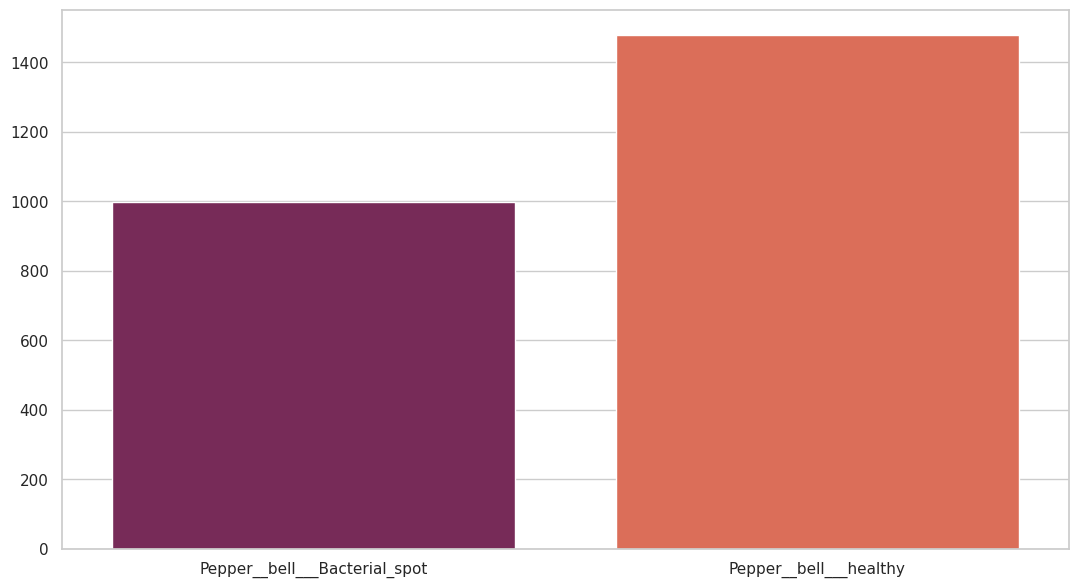

Weight for class 0: 0.62
Weight for class 1: 0.42


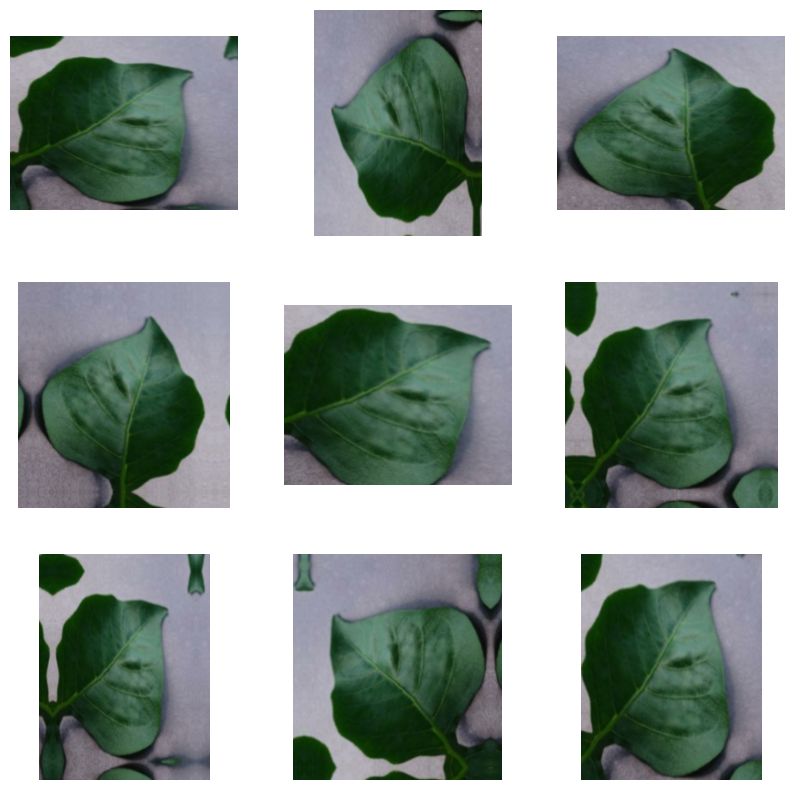

In [2]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Import RandomFlip and RandomRotation from the preprocessing module
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D, LeakyReLU



IMG_SIZE = (224, 224) # resolution
directory = "/kaggle/input/pepper-bell-leaf-diseases/Pepper__bell Leaf Diseases Dataset From Bangladesh"
BATCH_SIZE = 64
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             validation_split=0.1,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)



class_names = train_dataset.class_names
class_names
     


sns.set_theme(style="whitegrid")
Data_imbalance = []
for folder in os.listdir(directory):
    files = gb.glob(pathname=str(directory + "/" + folder +"/*.*"))
    Data_imbalance.append(len(files))
plt.figure(figsize=(13,7))
sns.barplot(x=['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy'], y=Data_imbalance, palette="rocket")
plt.show()



total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))



data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])


for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')
     


AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D

# Load ResNet50 without top layers and with imagenet weights
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False


94765736/94765736 [==============================] - 4s 0us/step


In [4]:
# Add custom layers on top of ResNet50
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # apply augmentation
x = tf.keras.applications.resnet.preprocess_input(x)  # normalize for ResNet
x = base_model(x, training=False)  # pass through ResNet50
x = GlobalAveragePooling2D()(x)  # Avg Pool
x = Flatten()(x)  # Flatten
x = Dense(256, activation='relu')(x)  # FC layer
x = Dropout(0.5)(x)
outputs = Dense(4, activation='softmax')(x)  # Final output layer for 4 classes

model = Model(inputs, outputs)


In [5]:
from tensorflow.keras.optimizers import Adam

# Define optimizer with custom learning rate
learning_rate = 1e-4  # You can tweak this later for fine-tuning
optimizer = Adam(learning_rate=learning_rate)

# Compile with custom optimizer
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [6]:
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, None, None, 3)     0         
                                                                 
 tf.__operators__.getitem (S  (None, None, None, 3)    0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, None, None, 3)    0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                      

In [7]:
Plant_Leaf_Model = model  # just to clarify


In [8]:
history = Plant_Leaf_Model.fit(
    train_dataset,                    # Training dataset
    epochs=10,                        # Number of epochs
    verbose=2,                        # Readable output format
    class_weight=class_weight,       # Handle class imbalance
    validation_data=validation_dataset  # Validation dataset
)


Epoch 1/10
35/35 - 192s - loss: 0.4125 - accuracy: 0.6109 - val_loss: 0.5448 - val_accuracy: 0.6923 - 192s/epoch - 5s/step
Epoch 2/10
35/35 - 189s - loss: 0.1634 - accuracy: 0.8604 - val_loss: 0.2572 - val_accuracy: 0.9069 - 189s/epoch - 5s/step
Epoch 3/10
35/35 - 188s - loss: 0.1017 - accuracy: 0.9309 - val_loss: 0.1691 - val_accuracy: 0.9474 - 188s/epoch - 5s/step
Epoch 4/10
35/35 - 179s - loss: 0.0825 - accuracy: 0.9408 - val_loss: 0.1296 - val_accuracy: 0.9636 - 179s/epoch - 5s/step
Epoch 5/10
35/35 - 197s - loss: 0.0690 - accuracy: 0.9533 - val_loss: 0.0907 - val_accuracy: 0.9757 - 197s/epoch - 6s/step
Epoch 6/10
35/35 - 193s - loss: 0.0675 - accuracy: 0.9574 - val_loss: 0.0688 - val_accuracy: 0.9879 - 193s/epoch - 6s/step
Epoch 7/10
35/35 - 195s - loss: 0.0553 - accuracy: 0.9704 - val_loss: 0.0555 - val_accuracy: 0.9919 - 195s/epoch - 6s/step
Epoch 8/10
35/35 - 177s - loss: 0.0507 - accuracy: 0.9654 - val_loss: 0.0562 - val_accuracy: 0.9879 - 177s/epoch - 5s/step
Epoch 9/10
35/35

In [9]:
# Evaluate the model on the validation dataset
validation_loss, validation_accuracy = Plant_Leaf_Model.evaluate(validation_dataset, verbose=1)

# Print the evaluation results
print(f"Validation Loss: {validation_loss}")
print(f"Validation Accuracy: {validation_accuracy}")

4/4 [==============================] - 18s 4s/step - loss: 0.0693 - accuracy: 0.9798
Validation Loss: 0.06929121166467667
Validation Accuracy: 0.9797570705413818


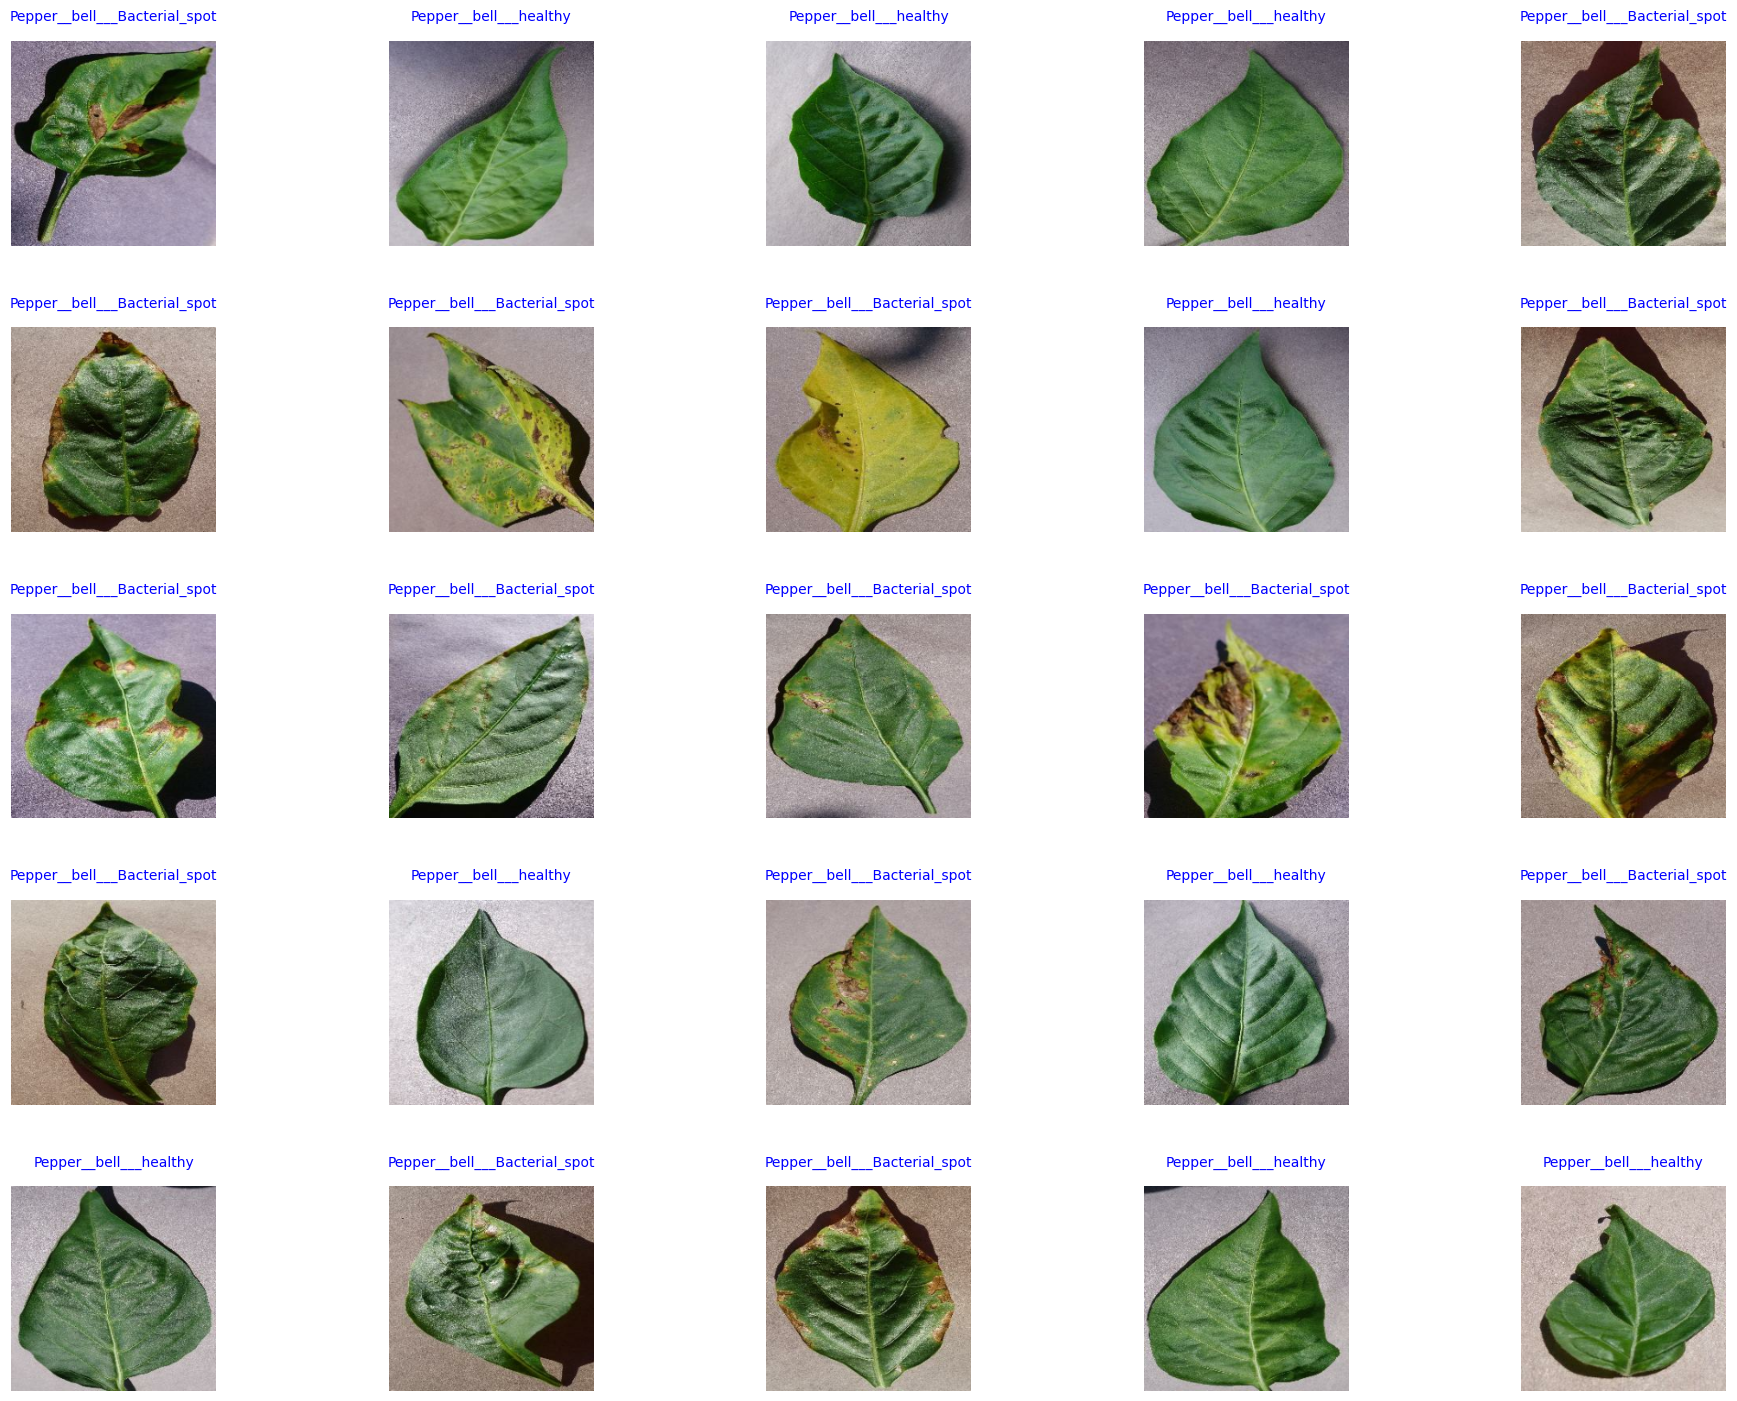

In [10]:
plt.figure(figsize=(20, 15))

# Take one batch from the training dataset
for images, labels in train_dataset.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        
        # Get image and label
        image = images[i]
        label = labels[i].numpy()
        
        # Expand dims and predict
        img_array = tf.expand_dims(image, 0)  # Shape: (1, 224, 224, 3)
        prediction = Plant_Leaf_Model.predict(img_array, verbose=0)
        predicted_class = class_names[np.argmax(prediction)]
        actual_class = class_names[label]

        # Display image
        plt.imshow(image.numpy().astype("uint8"))
        plt.axis("off")
        
        # Title coloring logic
        color = 'blue' if predicted_class == actual_class else 'red'
        plt.title(predicted_class, fontsize=10, color=color, pad=15)

    plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95,
                        top=0.95, wspace=0.3, hspace=0.4)
plt.show()


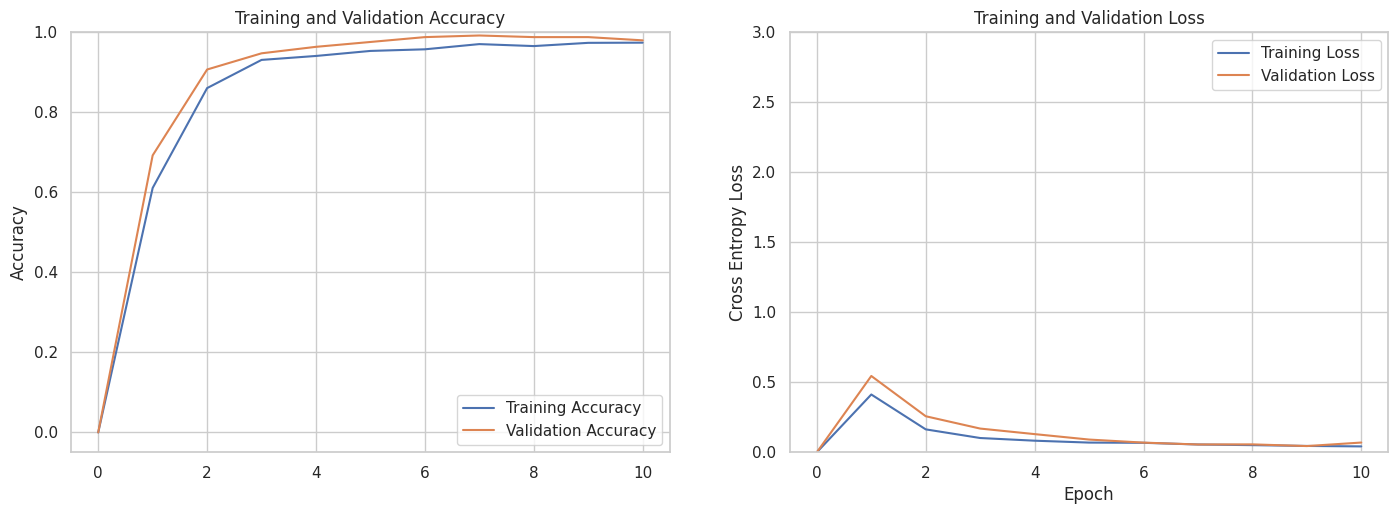

In [11]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = [0.] + history.history['loss']
val_loss = [0.] + history.history['val_loss']

plt.figure(figsize=(17, 12))

# Accuracy Plot
plt.subplot(2, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()), 1])
plt.title('Training and Validation Accuracy')

# Loss Plot
plt.subplot(2, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy Loss')
plt.ylim([0, 3.0])
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')

plt.show()


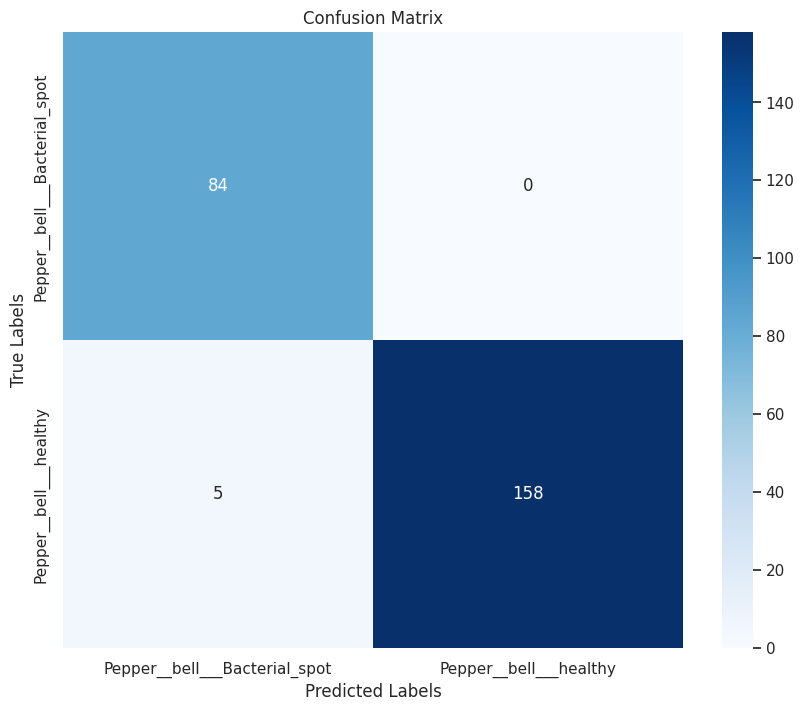

Confusion Matrix:
 [[ 84   0]
 [  5 158]]

Classification Report:

                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       0.94      1.00      0.97        84
       Pepper__bell___healthy       1.00      0.97      0.98       163

                     accuracy                           0.98       247
                    macro avg       0.97      0.98      0.98       247
                 weighted avg       0.98      0.98      0.98       247



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true and predicted labels
true_labels = []
predicted_labels = []

for images, labels in validation_dataset:
    predictions = Plant_Leaf_Model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_classes)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print confusion matrix and classification report
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))
